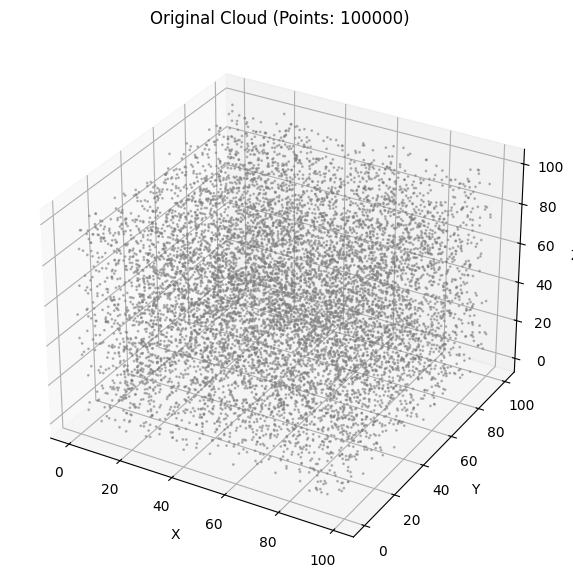

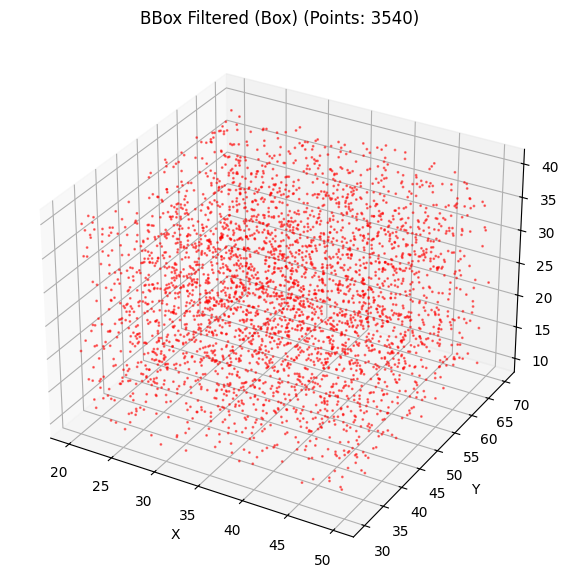

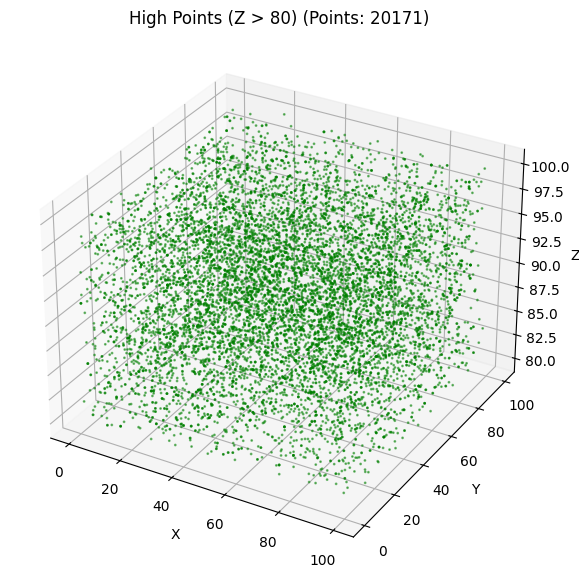

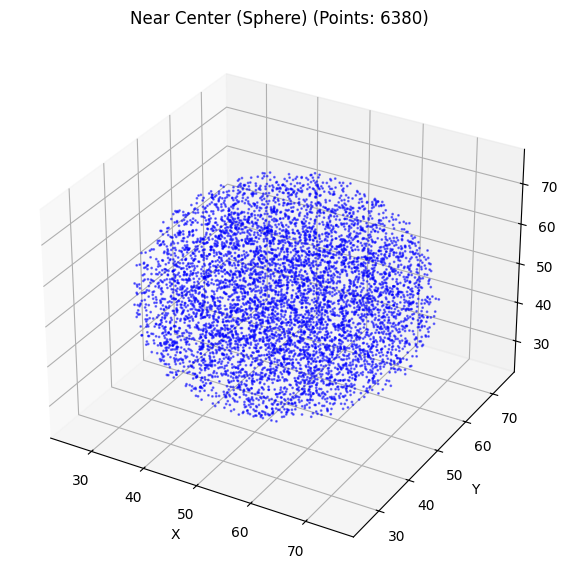

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def filter_by_bbox(points, xmin, xmax, ymin, ymax, zmin, zmax):
    mask = (
        (points[:, 0] >= xmin) & (points[:, 0] <= xmax) &
        (points[:, 1] >= ymin) & (points[:, 1] <= ymax) &
        (points[:, 2] >= zmin) & (points[:, 2] <= zmax)
    )
    return points[mask]

def filter_by_distance(points, center, radius):
    distances = np.linalg.norm(points - center, axis=1)
    return points[distances <= radius]

def show_cloud(points, title="Point Cloud", color='blue'):
    fig = plt.figure(figsize=(10, 7))
    ax = fig.add_subplot(111, projection='3d')
    display_points = points if len(points) < 10000 else points[np.random.choice(len(points), 10000)]
    
    ax.scatter(display_points[:, 0], display_points[:, 1], display_points[:, 2], s=1, c=color, alpha=0.5)
    ax.set_title(f"{title} (Points: {len(points)})")
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    plt.show()


points = np.random.uniform(0, 100, size=(100000, 3))
np.savetxt("synthetic_cloud.xyz", points)

filtered_bbox = filter_by_bbox(points, 20, 50, 30, 70, 10, 40)

high_points = points[points[:, 2] > 80]

center = np.array([50, 50, 50])
radius = 25
near_center = filter_by_distance(points, center, radius)


np.savetxt("bbox_filtered.xyz", filtered_bbox)
np.savetxt("high_points.xyz", high_points)
np.savetxt("near_center.xyz", near_center)


show_cloud(points, "Original Cloud", color='gray')
show_cloud(filtered_bbox, "BBox Filtered (Box)", color='red')
show_cloud(high_points, "High Points (Z > 80)", color='green')
show_cloud(near_center, "Near Center (Sphere)", color='blue')